<div align="center">
<h1>Online Shoppers Intention</h1>
</div>

#### Problem Statement:

Based on given data of visitors browsing for online shopping, build different clusters to know whether person is only browsing and visiting multiples pages or also generating revenue for the shoppers as well.  Analyse and compare the clusters formed with the existing Revenue Column.

In [1]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import seaborn as sns

pd.options.display.max_columns = None
pd.options.display.float_format='{:.6f}'.format

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import silhouette_samples,silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df_shoppers = pd.read_csv('online_shoppers_intention.csv')
df_shoppers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.000000,0,0.000000,2,64.000000,0.000000,0.100000,0.000000,0.000000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.000000,0,0.000000,2,2.666667,0.050000,0.140000,0.000000,0.000000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.000000,0,0.000000,10,627.500000,0.020000,0.050000,0.000000,0.000000,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df_shoppers.shape

(12330, 18)

There are 12330 rows and 18 columns.

In [4]:
df_shoppers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

There are 14 numerical and 4 categorical columns. But as per data definition there are 10 numerical and 8 categorical columns.Converting then to their specified data type 

In [5]:
df_shoppers.iloc[:,[11,12,13,14,16,17]] = df_shoppers.iloc[:,[11,12,13,14,16,17]].astype(object)

In [6]:
df_shoppers.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems            object
Browser                     object
Region                      object
TrafficType                 object
VisitorType                 object
Weekend                     object
Revenue                     object
dtype: object

In [7]:
df_shoppers.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


In [8]:
df_shoppers.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330,12330,12330,12330,12330,12330,12330,12330
unique,10,8,13,9,20,3,2,2
top,May,2,2,1,2,Returning_Visitor,False,False
freq,3364,6601,7961,4780,3913,10551,9462,10422


### Perform required cleaning to bring the uniformity in the data.

In [9]:
df_shoppers.isnull().sum()
# no missing values in the dataset

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [10]:
df_shoppers[df_shoppers.duplicated()==True]
# There are duplicated values in the dataset

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Mar,2,2,4,1,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11934,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Dec,1,1,1,2,New_Visitor,False,False
11938,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Dec,1,1,4,1,Returning_Visitor,True,False
12159,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Dec,1,1,1,3,Returning_Visitor,False,False
12180,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Dec,1,13,9,20,Returning_Visitor,False,False


In [11]:
df_shoppers.drop_duplicates(inplace=True)
df_shoppers = df_shoppers.reset_index(drop=True)

### Perform required cleaning to bring the uniformity in the data.

UNIVARIANTE ANALYSIS: Distribution of numeric variables


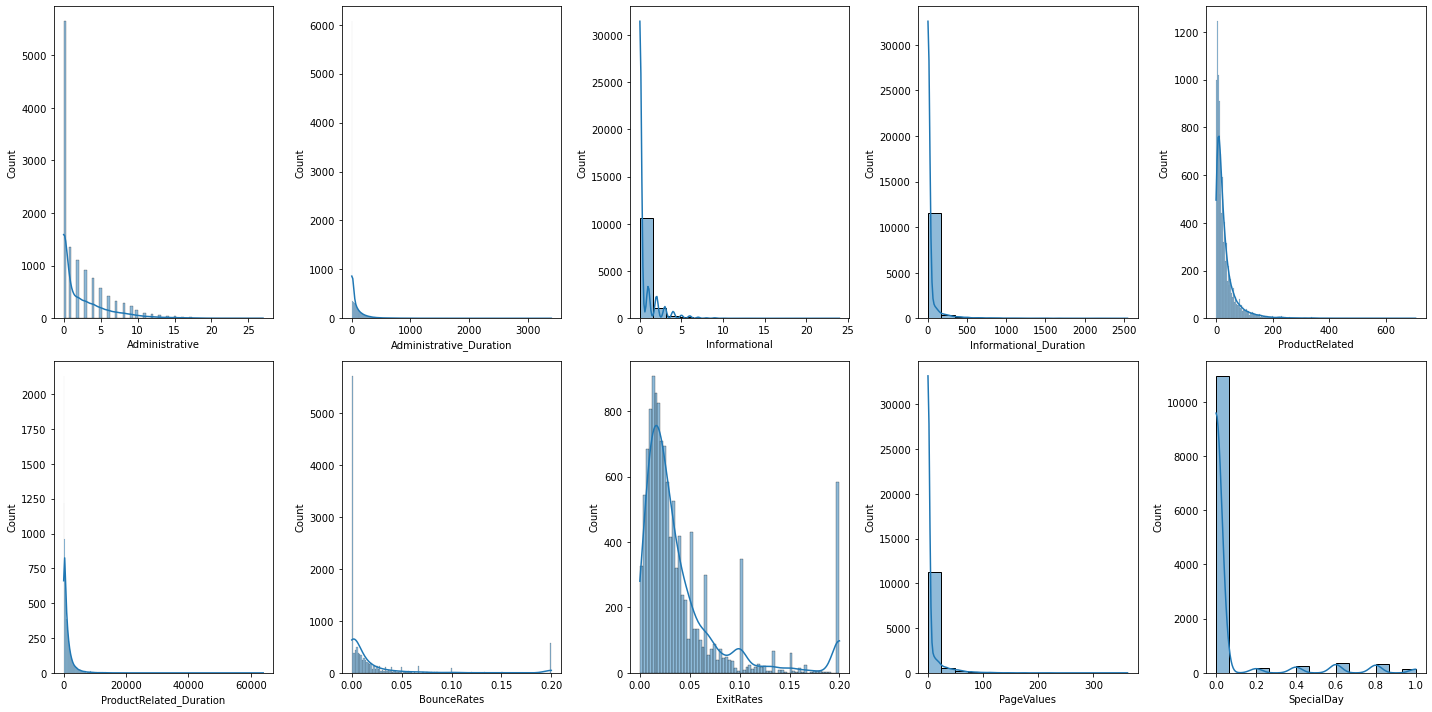

In [12]:
print('UNIVARIANTE ANALYSIS: Distribution of numeric variables')
fig, ax = plt.subplots(2,5,figsize=(20,10))

for var,subplot in zip(df_shoppers.select_dtypes(np.number).columns,ax.flatten()):
    sns.histplot(x=df_shoppers[var],ax=subplot,kde=True)
plt.tight_layout()
plt.show()
# All the numeric data is right skewd and has potential outliers

UNIVARIANTE ANALYSIS: Distribution of numeric variables


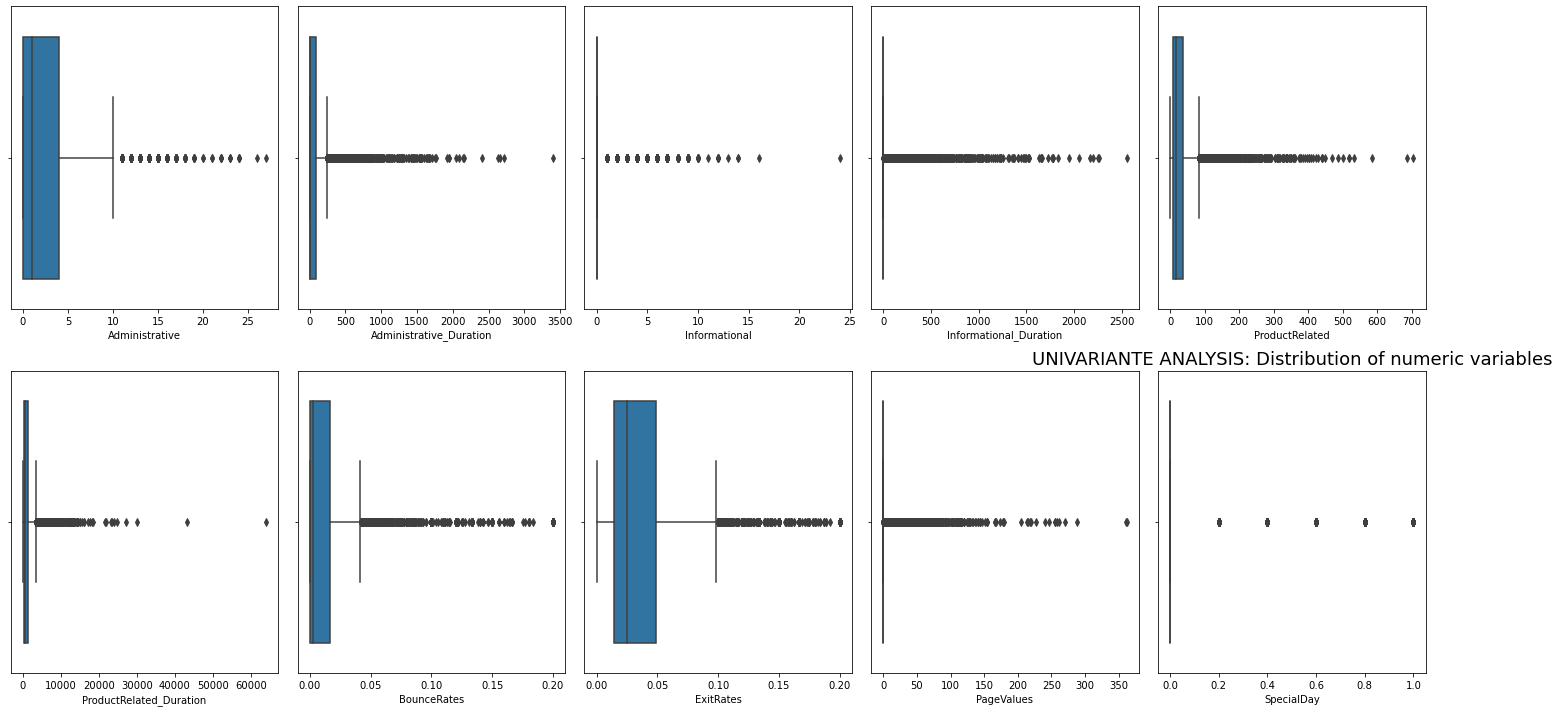

In [13]:
print('UNIVARIANTE ANALYSIS: Distribution of numeric variables')
fig, ax = plt.subplots(2,5,figsize=(20,10))

for var,subplot in zip(df_shoppers.select_dtypes(np.number).columns,ax.flatten()):
    sns.boxplot(x=df_shoppers[var],ax=subplot)
plt.title('UNIVARIANTE ANALYSIS: Distribution of numeric variables',fontsize=18)
plt.tight_layout()
plt.show()
# there are many outliers, we treat the outliers

UNIVARIANTE ANALYSIS: Distribution of categorical variables


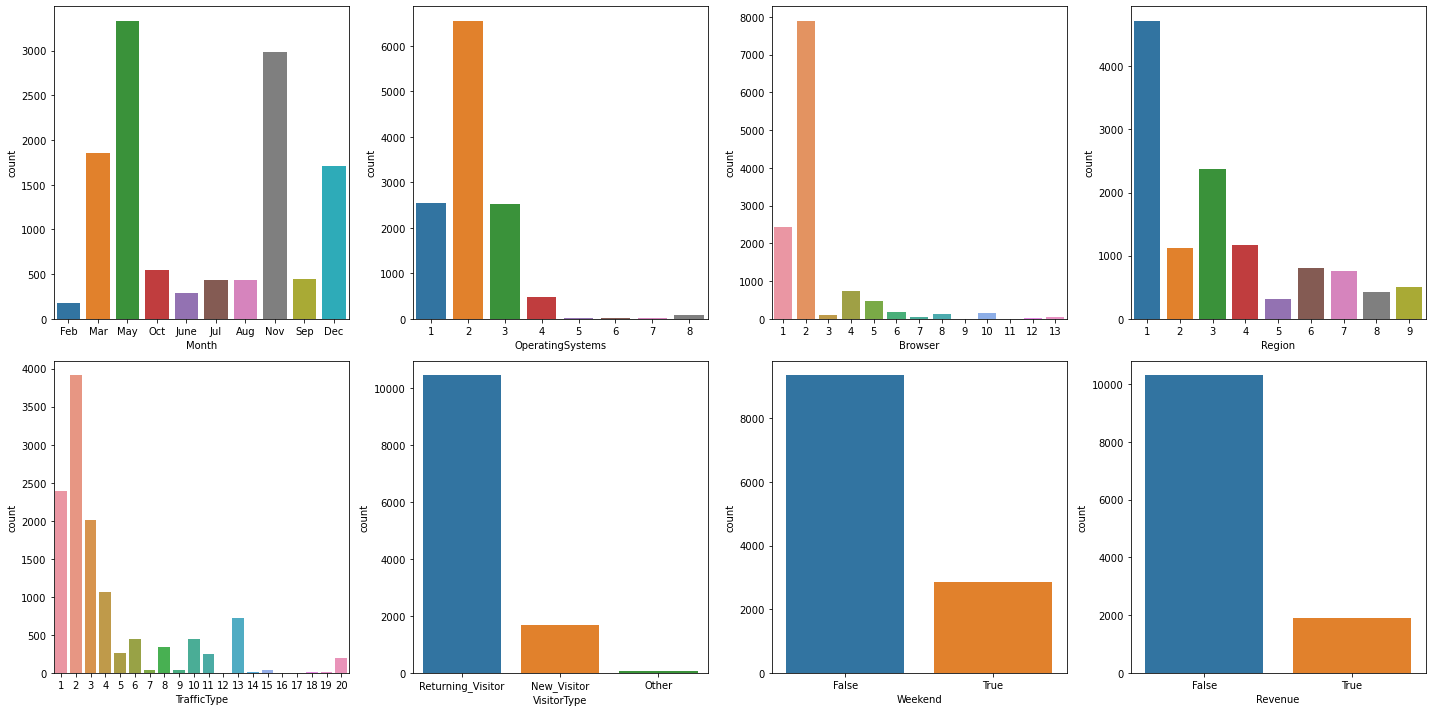

In [14]:
print('UNIVARIANTE ANALYSIS: Distribution of categorical variables')
fig, ax = plt.subplots(2,4,figsize=(20,10))

for var,subplot in zip(df_shoppers.select_dtypes(object).columns,ax.flatten()):
    sns.countplot(x=df_shoppers[var],ax=subplot)
plt.tight_layout()
plt.show()

In [15]:
# highest observations are in the month may followed by november and least observation is in the month february
# highest operating system is type2, browser is type 2 and region 1
# Highest traffictype is highest in type2, highest vistior type is returning type.
# Most of the shoppers visit on week day and most shoppers don't generate revenue.

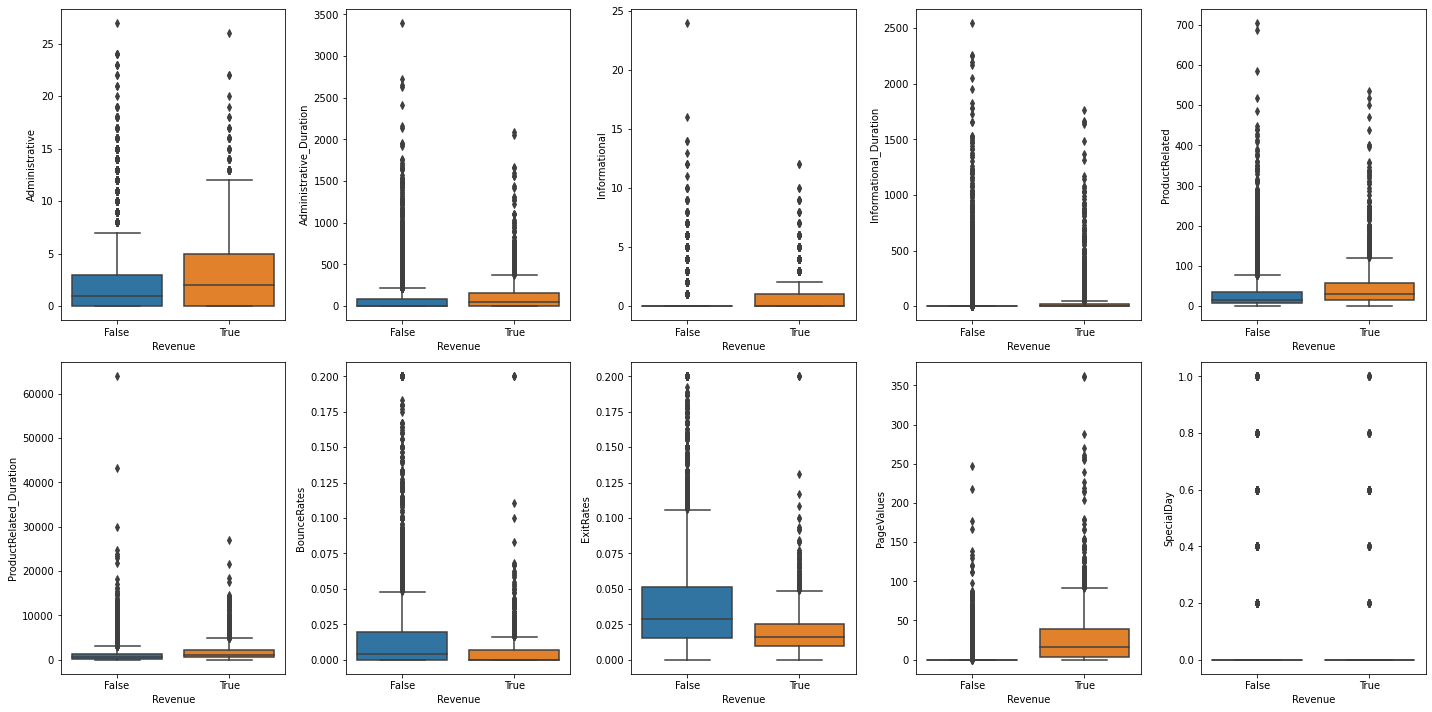

In [16]:
## Bivariate Analysis with Revenue
fig,ax = plt.subplots(2,5,figsize=(20,10))

for i,subplot in zip(df_shoppers.select_dtypes(np.number),ax.flatten()):
    sns.boxplot(y=df_shoppers[i], x=df_shoppers['Revenue'],ax=subplot)
plt.tight_layout()
plt.show()

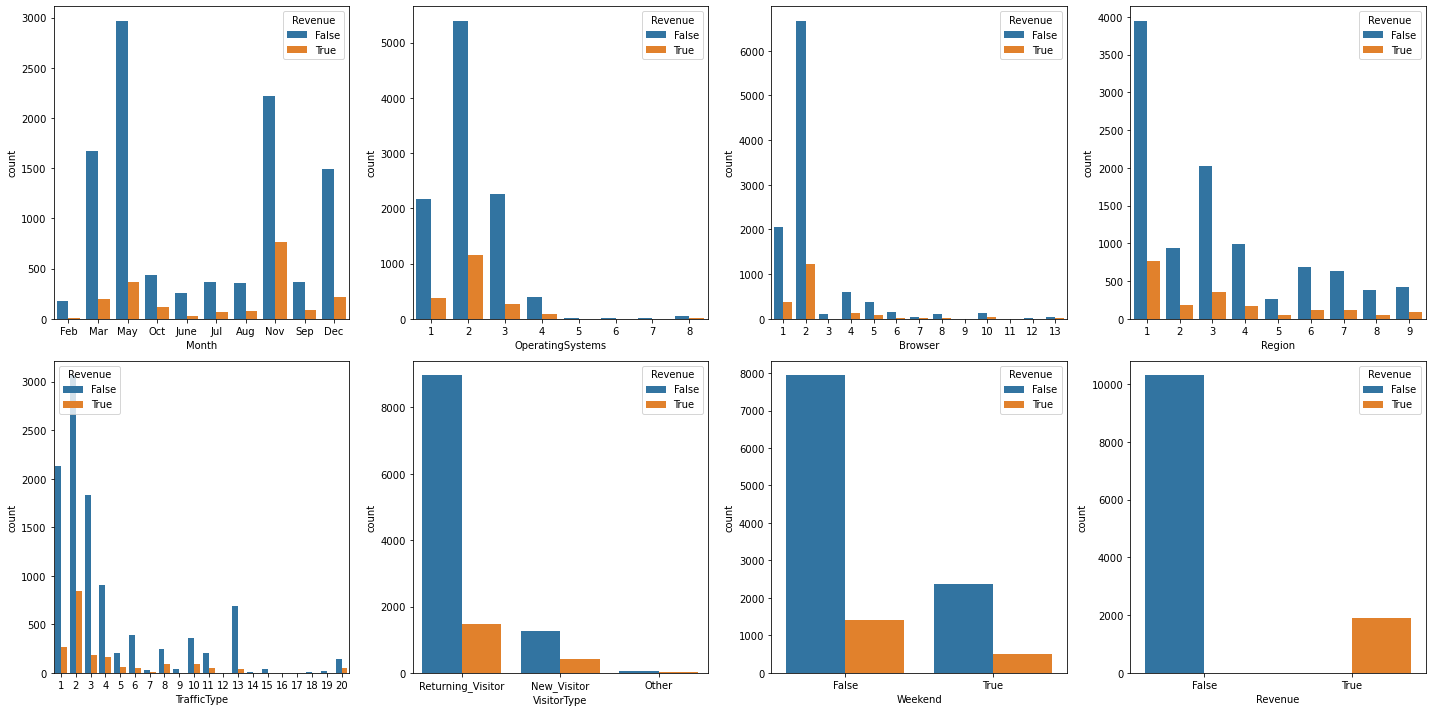

In [17]:
fig,ax = plt.subplots(2,4,figsize=(20,10))

for i,subplot in zip(df_shoppers.select_dtypes(object),ax.flatten()):
    sns.countplot(x=df_shoppers[i], hue=df_shoppers['Revenue'],ax=subplot)
plt.tight_layout()
plt.show()

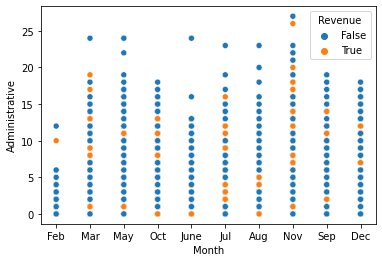

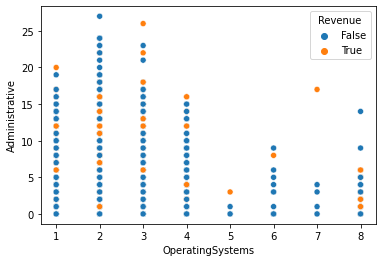

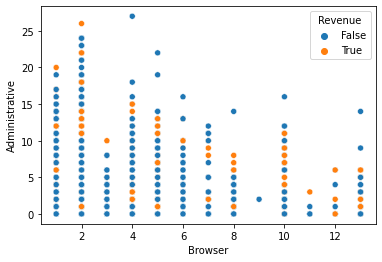

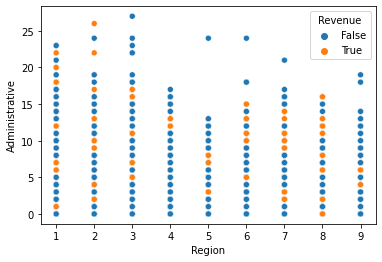

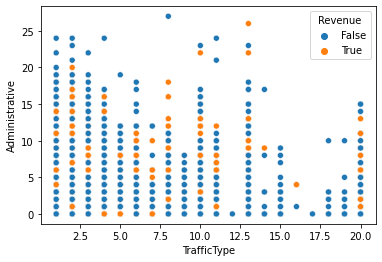

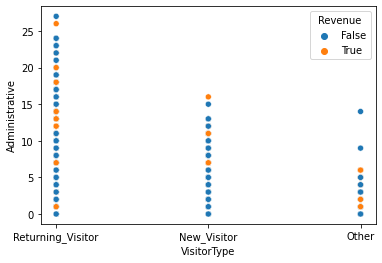

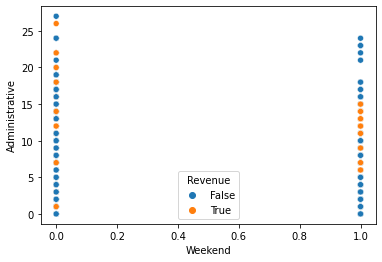

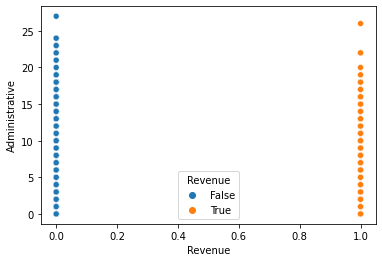

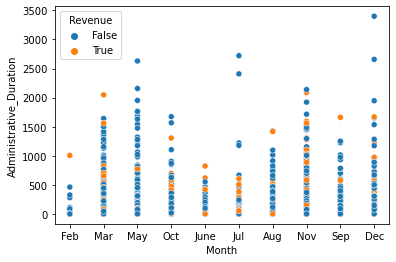

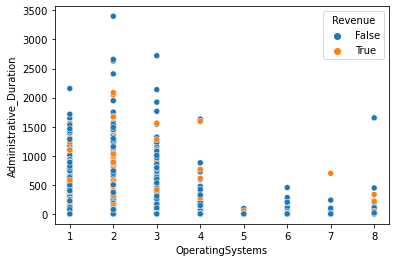

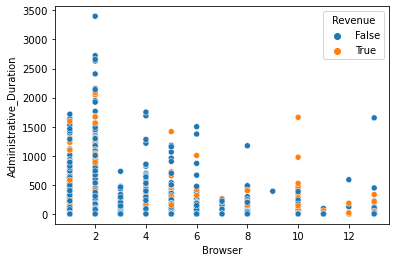

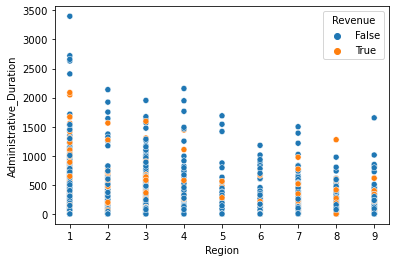

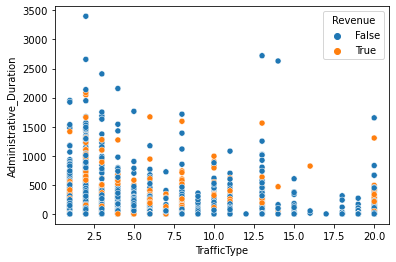

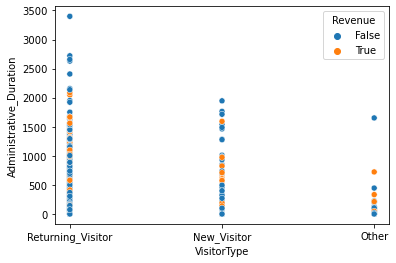

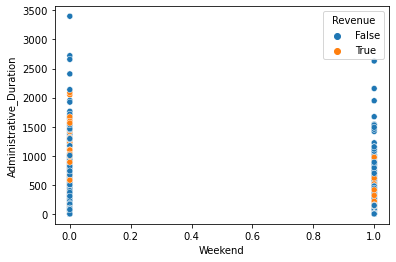

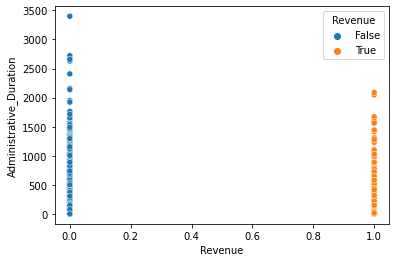

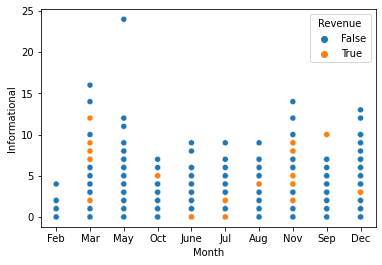

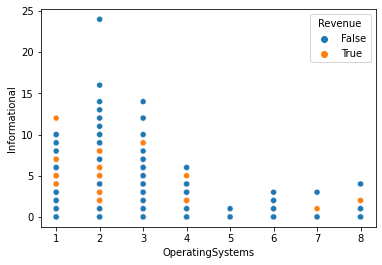

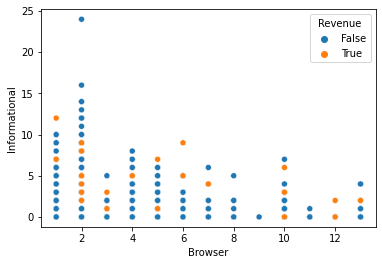

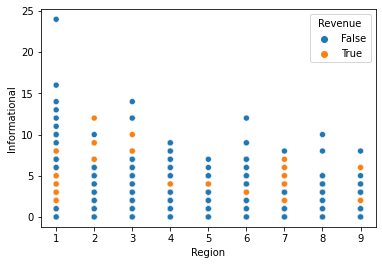

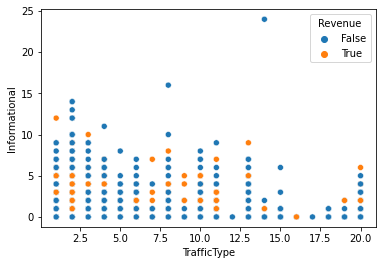

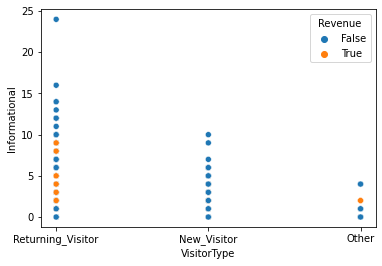

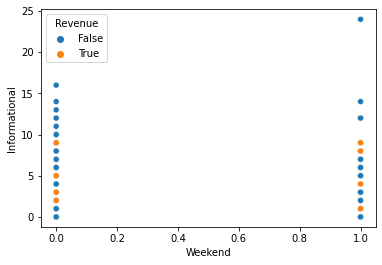

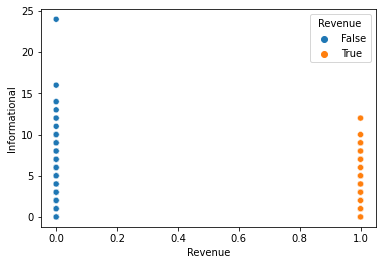

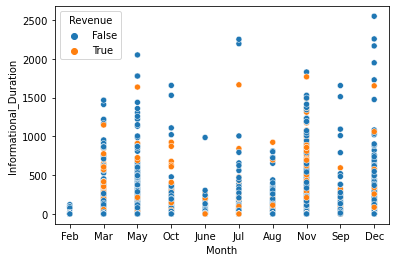

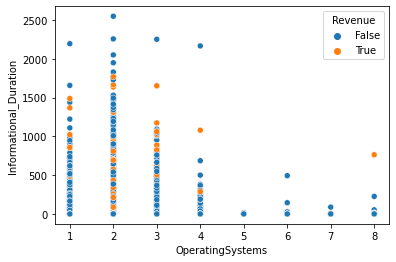

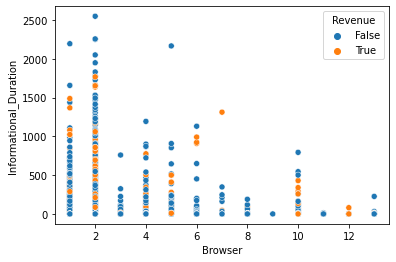

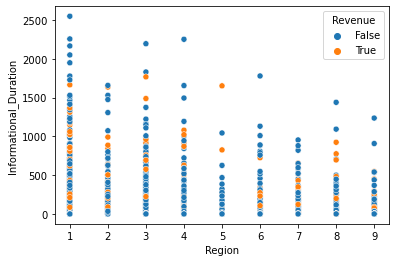

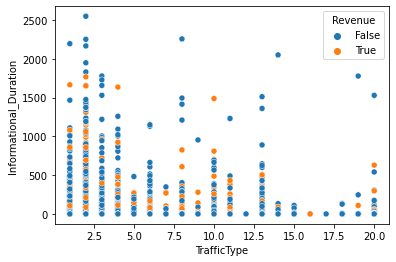

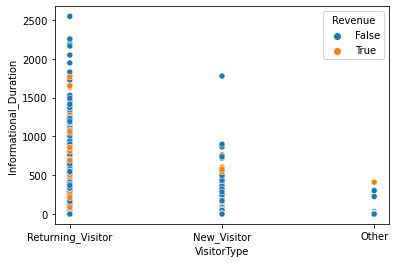

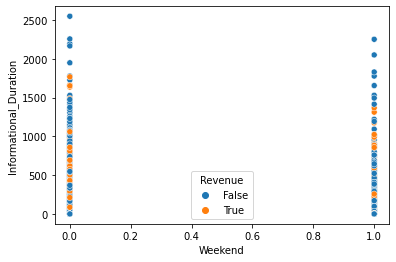

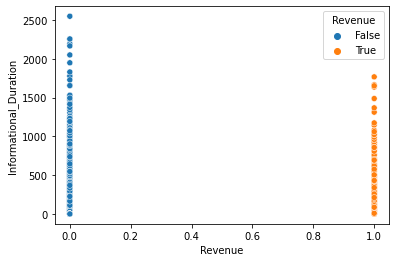

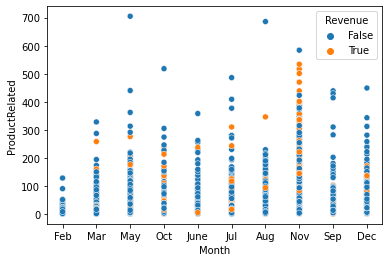

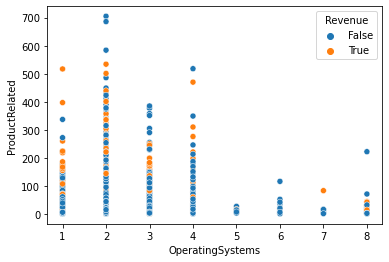

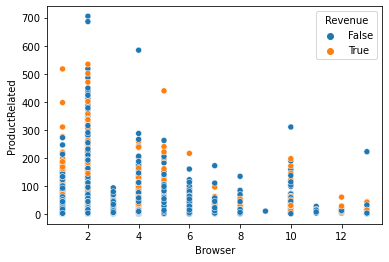

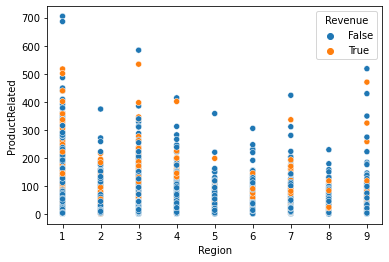

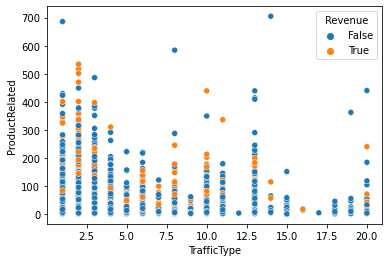

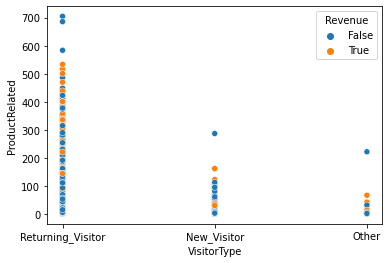

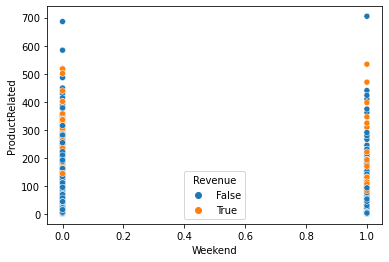

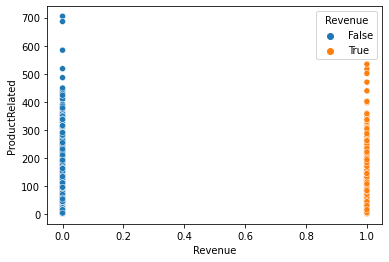

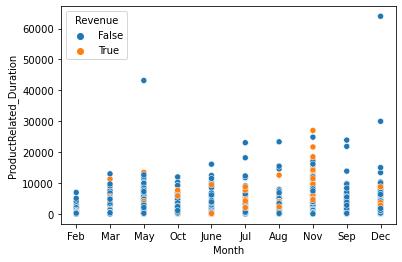

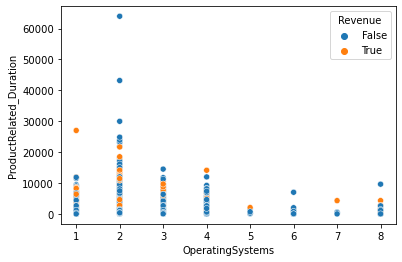

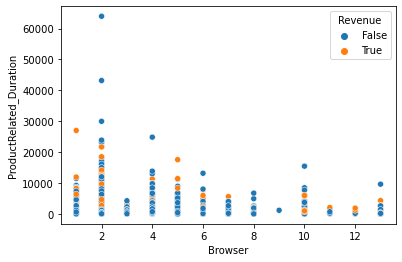

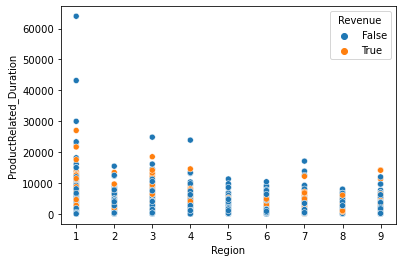

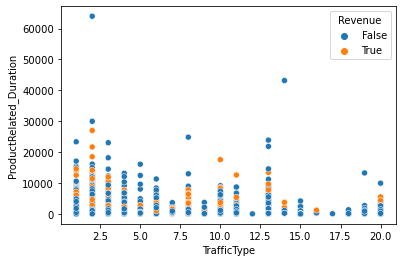

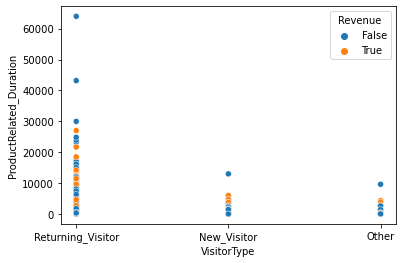

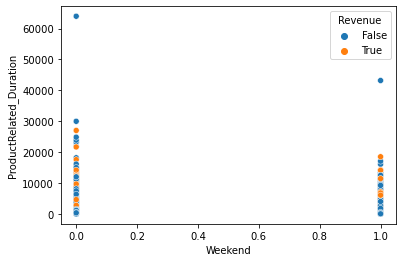

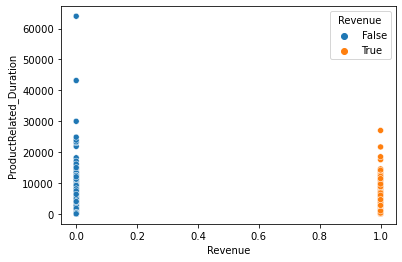

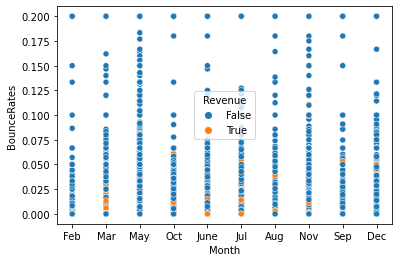

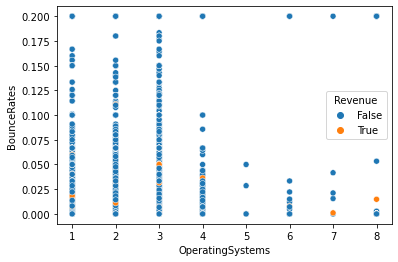

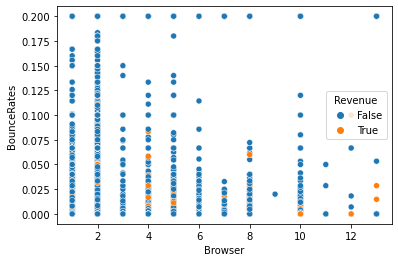

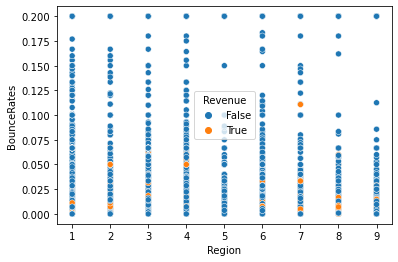

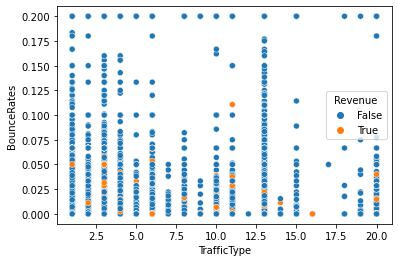

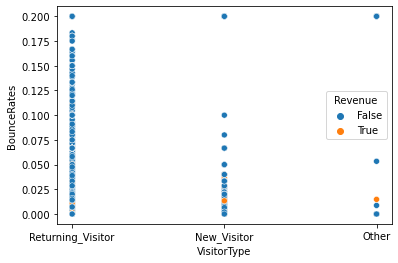

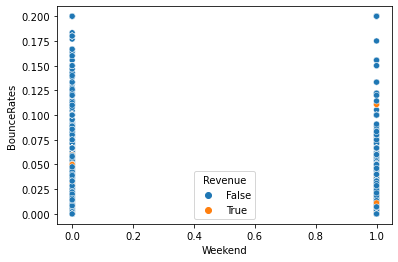

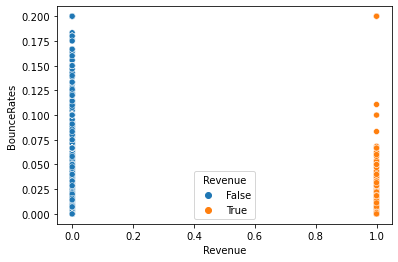

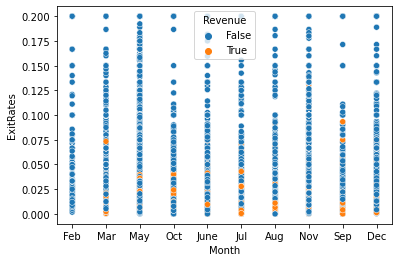

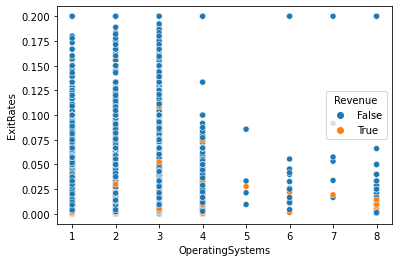

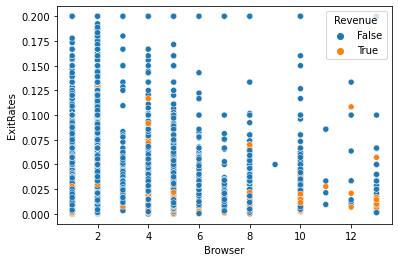

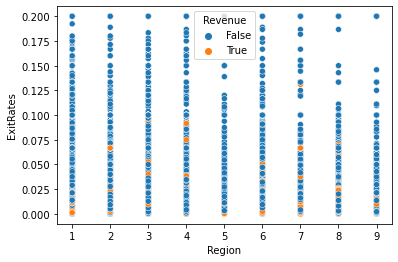

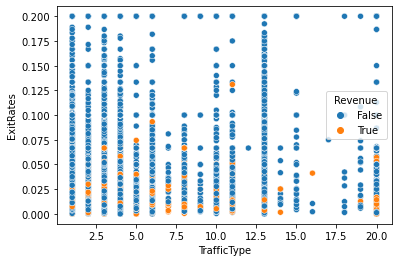

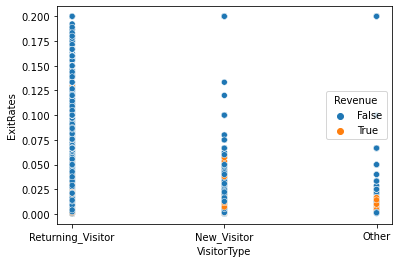

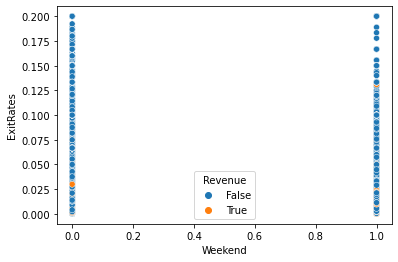

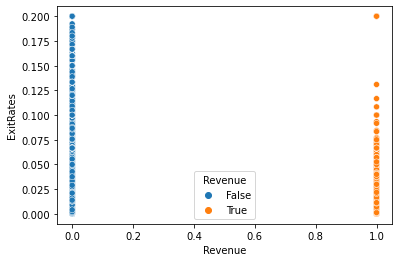

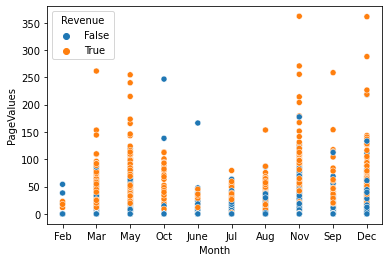

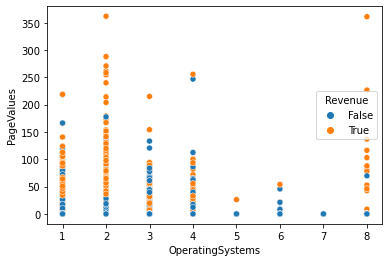

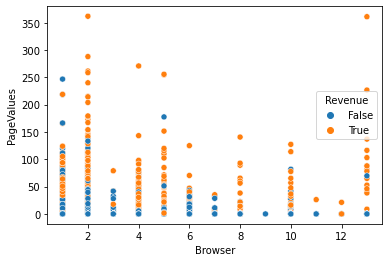

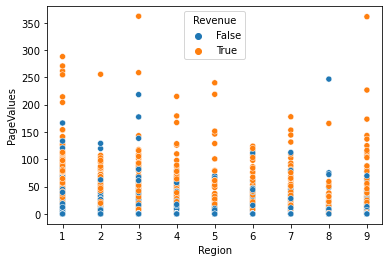

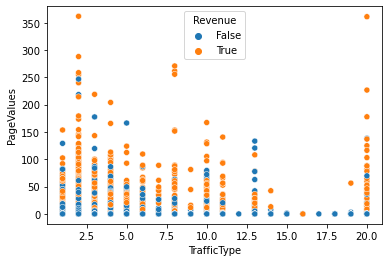

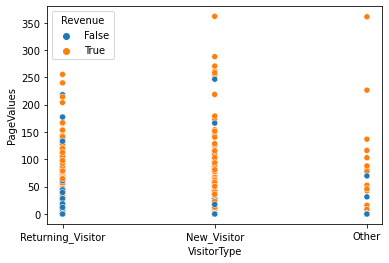

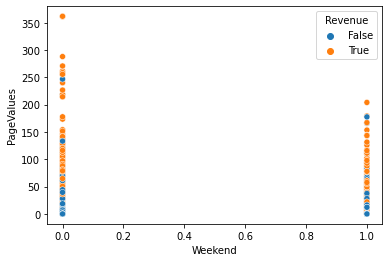

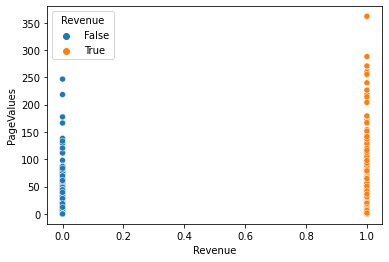

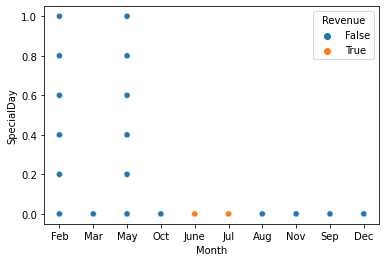

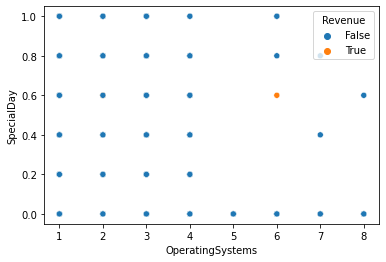

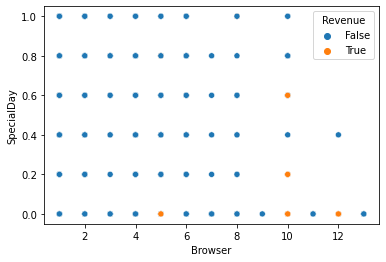

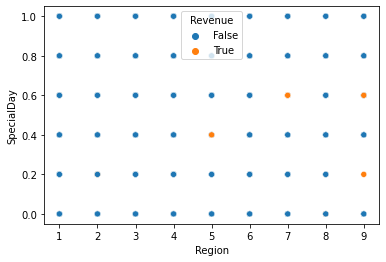

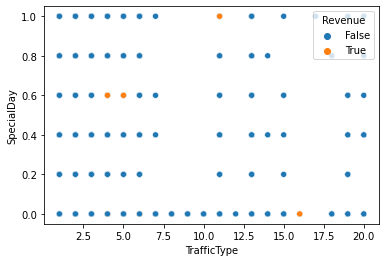

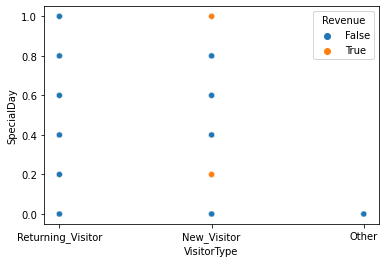

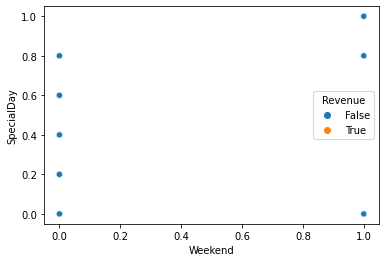

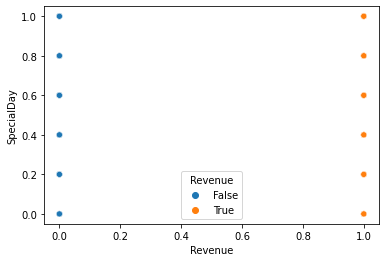

In [18]:
# Multivariate Analysis with target variable

df_categorical = df_shoppers.select_dtypes(object)
df_num = df_shoppers.select_dtypes(np.number)

for i in df_num:
    for j in df_categorical:
        sns.scatterplot(x=df_shoppers[j], y=df_shoppers[i], hue=df_shoppers['Revenue'])
        plt.show()

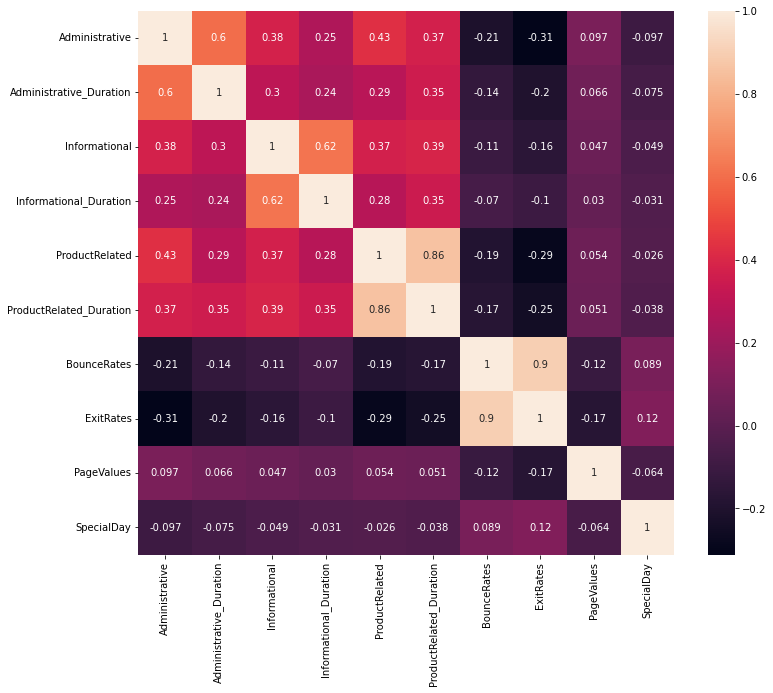

In [19]:
plt.figure(figsize=(12,10))
sns.heatmap(df_shoppers.corr(),annot=True)
plt.show()

In [20]:
# There is a moderate correlation between productrelated and productrelated_duration

### Perform required missing value treatment

In [21]:
df_shoppers.isnull().sum().sum()
# no missing values in the dataset

0

### Perform Outlier treatment if required

In [22]:
q1 = df_shoppers.quantile(0.25)
q3 = df_shoppers.quantile(0.75)
iqr = q3-q1

df_shoppers = df_shoppers[~((df_shoppers<(q1-1.5*iqr)) | (df_shoppers>(q3+1.5*iqr))).any(axis=1)].reset_index(drop=True)

C:\Users\npadh\AppData\Local\Temp/ipykernel_23148/551737189.py:5: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version.  Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  df_shoppers = df_shoppers[~((df_shoppers<(q1-1.5*iqr)) | (df_shoppers>(q3+1.5*iqr))).any(axis=1)].reset_index(drop=True)


In [23]:
df_num = df_shoppers.select_dtypes(np.number)

### Perform appropriate scaling

In [24]:
SS = StandardScaler()
X_scaled = pd.DataFrame(SS.fit_transform(df_num),columns=df_num.columns)
X_scaled.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
0,-0.684024,-0.633256,0.000000,0.000000,-0.560960,-0.049077,1.279791,1.058424,0.000000,0.000000
1,-0.684024,-0.633256,0.000000,0.000000,0.000544,-0.756838,0.877542,-0.252408,0.000000,0.000000
2,-0.684024,-0.633256,0.000000,0.000000,-0.997685,-0.396764,-0.630892,1.917244,0.000000,0.000000
3,-0.684024,-0.633256,0.000000,0.000000,-0.748128,-0.567990,-0.630892,-0.045774,0.000000,0.000000
4,-0.684024,-0.633256,0.000000,0.000000,-0.810517,-0.840906,-0.630892,1.917244,0.000000,0.000000


### Perform required encoding techniques

In [25]:
df_cat = df_categorical.drop('Revenue',axis=1)
X_dummies = pd.get_dummies(df_cat,drop_first=True)

from sklearn.preprocessing import LabelEncoder as LE
y = LE().fit_transform(df_categorical['Revenue'])
y[0:5]

array([0, 0, 0, 0, 0])

### Finding optimal number of clusters and clustering

In [26]:
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

wcss

[30264.0,
 22823.37340652578,
 17847.999470248684,
 13954.015765977532,
 12140.880865358235,
 11080.054313648885,
 10247.08342804872,
 9556.679867469116,
 8983.315219539176,
 8455.851126080484]

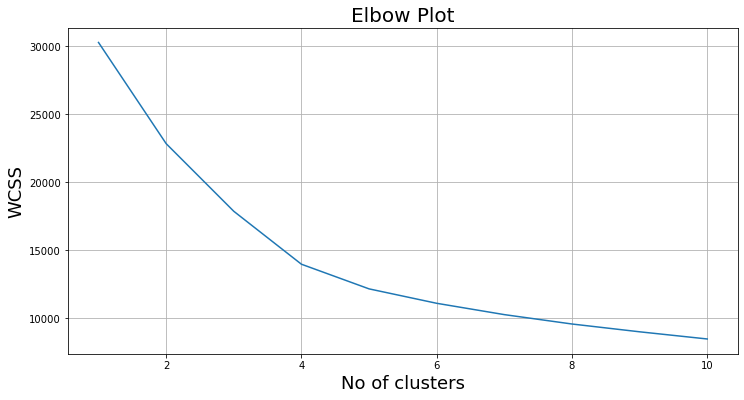

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(range(1, 11), wcss)

plt.xlabel('No of clusters',fontsize=18)
plt.ylabel('WCSS',fontsize=18)
plt.title('Elbow Plot',fontsize=20)

plt.grid(True)
plt.show()
# k=4 seems like a optimal value

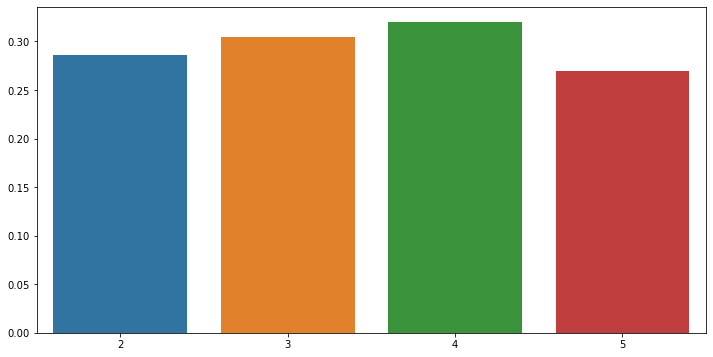

In [28]:
score = []

k = [2,3,4,5]
for i in k:
    km = KMeans(n_clusters=i, random_state=10)
    predict = km.fit_predict(X_scaled)
    score.append(silhouette_score(X_scaled, predict))

plt.figure(figsize=(12,6))
sns.barplot(x=k,y=score)
plt.show()
# The silhouette score is highest for k=4,it is optimal clusters

In [29]:
kmeans = KMeans(n_clusters=4, random_state=10)
kmeans.fit(X_scaled)
df_shoppers['Cluster'] = kmeans.labels_
df_shoppers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Cluster
0,0,0.000000,0,0.000000,10,627.500000,0.020000,0.050000,0.000000,0.000000,Feb,3,3,1,4,Returning_Visitor,True,False,0
1,0,0.000000,0,0.000000,19,154.216667,0.015789,0.024561,0.000000,0.000000,Feb,2,2,1,3,Returning_Visitor,False,False,3
2,0,0.000000,0,0.000000,3,395.000000,0.000000,0.066667,0.000000,0.000000,Feb,1,1,3,3,Returning_Visitor,False,False,3
3,0,0.000000,0,0.000000,7,280.500000,0.000000,0.028571,0.000000,0.000000,Feb,1,1,1,3,Returning_Visitor,False,False,3
4,0,0.000000,0,0.000000,6,98.000000,0.000000,0.066667,0.000000,0.000000,Feb,2,5,1,3,Returning_Visitor,False,False,3


### Business interpretation using the cluster centroids.Perform EDA on cluster groups to understand the cluster characteristics.


In [64]:
df_shoppers['Cluster'].value_counts()

3    2407
2    1055
1     803
0     779
Name: Cluster, dtype: int64

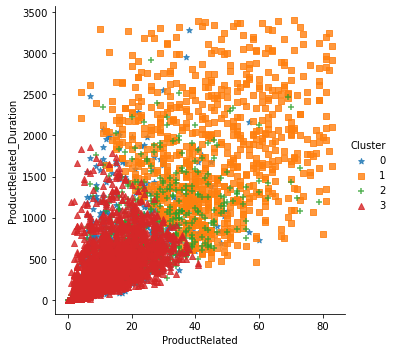

In [31]:
sns.lmplot(x='ProductRelated',y='ProductRelated_Duration',hue='Cluster',
           data=df_shoppers,fit_reg=False,markers=['*',',','+','^'])
plt.show()

In [66]:
kmeans.cluster_centers_

array([[-0.40284558, -0.38107757,  0.        ,  0.        , -0.25982505,
        -0.20302974,  1.88167541,  1.20341012,  0.        ,  0.        ],
       [-0.13481327, -0.19304078,  0.        ,  0.        ,  1.60557354,
         1.65053593, -0.04933184, -0.44627872,  0.        ,  0.        ],
       [ 1.45905054,  1.5240844 ,  0.        ,  0.        , -0.0120519 ,
        -0.13713023, -0.25961358, -0.54078118,  0.        ,  0.        ],
       [-0.46415727, -0.48028163,  0.        ,  0.        , -0.44626385,
        -0.42482251, -0.47873675, -0.00356067,  0.        ,  0.        ]])

In [ ]:
# from the cluster centroids 0 and cluster centroid 3 are i almost in the same range, also the plot shows that clusters are overlapped. so reclustering the again using PCA.

In [32]:
cluster0 = df_shoppers[df_shoppers['Cluster'] == 0]
cluster0.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Cluster
count,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000
mean,0.573813,13.221879,0.000000,0.000000,14.826701,524.551076,0.026300,0.052814,0.000000,0.000000,0.000000
std,1.124914,31.303351,0.000000,0.000000,9.349100,476.770319,0.008107,0.016410,0.000000,0.000000,0.000000
min,0.000000,0.000000,0.000000,0.000000,2.000000,8.000000,0.004545,0.011429,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,172.004167,0.020000,0.040683,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,12.000000,365.583333,0.025595,0.050425,0.000000,0.000000,0.000000
75%,1.000000,3.500000,0.000000,0.000000,20.000000,733.041667,0.033333,0.064744,0.000000,0.000000,0.000000
max,6.000000,222.500000,0.000000,0.000000,60.000000,3287.000000,0.041667,0.095238,0.000000,0.000000,0.000000


In [33]:
cluster0.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,779,779,779,779,779,779,779,779
unique,10,6,11,9,16,2,2,2
top,Nov,2,2,1,1,Returning_Visitor,False,False
freq,208,358,511,268,248,747,600,758


In [34]:
cluster1 = df_shoppers[df_shoppers['Cluster'] == 1]
cluster1.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Cluster
count,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000
mean,1.120797,23.080782,0.000000,0.000000,44.726027,1764.039847,0.006087,0.020799,0.000000,0.000000,1.000000
std,1.566196,35.589828,0.000000,0.000000,16.659257,697.063055,0.006885,0.012727,0.000000,0.000000,0.000000
min,0.000000,0.000000,0.000000,0.000000,4.000000,441.791667,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,33.000000,1209.782449,0.000000,0.010944,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,43.000000,1668.285119,0.004348,0.018841,0.000000,0.000000,1.000000
75%,2.000000,37.166667,0.000000,0.000000,57.000000,2251.625000,0.009850,0.028568,0.000000,0.000000,1.000000
max,9.000000,209.062500,0.000000,0.000000,83.000000,3401.050687,0.036508,0.068651,0.000000,0.000000,1.000000


In [35]:
cluster1.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,803,803,803,803,803,803,803,803
unique,10,5,10,9,14,3,2,2
top,Nov,2,2,1,2,Returning_Visitor,False,False
freq,295,494,555,324,270,715,612,760


In [36]:
cluster2 = df_shoppers[df_shoppers['Cluster'] == 2]
cluster2.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Cluster
count,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000
mean,4.373460,113.110879,0.000000,0.000000,18.798104,568.618413,0.003886,0.018965,0.000000,0.000000,2.000000
std,2.007306,50.801804,0.000000,0.000000,13.051278,478.541515,0.007140,0.012658,0.000000,0.000000,0.000000
min,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,3.000000,74.500000,0.000000,0.000000,9.000000,203.698333,0.000000,0.009190,0.000000,0.000000,2.000000
50%,4.000000,105.750000,0.000000,0.000000,16.000000,447.166667,0.000000,0.016434,0.000000,0.000000,2.000000
75%,6.000000,148.950000,0.000000,0.000000,26.000000,797.816667,0.005698,0.027273,0.000000,0.000000,2.000000
max,10.000000,236.000000,0.000000,0.000000,79.000000,2923.250000,0.041463,0.066667,0.000000,0.000000,2.000000


In [37]:
cluster2.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,1055,1055,1055,1055,1055,1055,1055,1055
unique,10,6,11,9,18,3,2,2
top,Nov,2,2,1,2,Returning_Visitor,False,False
freq,217,480,637,375,426,675,770,1004


In [38]:
cluster3 = df_shoppers[df_shoppers['Cluster'] == 3]
cluster3.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Cluster
count,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000
mean,0.448691,8.020540,0.000000,0.000000,11.838388,376.237125,0.001593,0.029391,0.000000,0.000000,3.000000
std,0.842406,17.194087,0.000000,0.000000,8.083730,323.573094,0.004032,0.018121,0.000000,0.000000,0.000000
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,0.000000,0.000000,0.000000,5.000000,125.500000,0.000000,0.015385,0.000000,0.000000,3.000000
50%,0.000000,0.000000,0.000000,0.000000,10.000000,277.000000,0.000000,0.025000,0.000000,0.000000,3.000000
75%,1.000000,4.000000,0.000000,0.000000,17.000000,549.291667,0.000000,0.040000,0.000000,0.000000,3.000000
max,4.000000,135.000000,0.000000,0.000000,41.000000,1859.500000,0.022222,0.088889,0.000000,0.000000,3.000000


In [39]:
cluster3.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,2407,2407,2407,2407,2407,2407,2407,2407
unique,10,8,12,9,19,3,2,2
top,Mar,2,2,1,2,Returning_Visitor,False,False
freq,579,1319,1468,959,781,1941,1843,2335


### Performing PCA and apply clustering on top of it. 

In [40]:
# finding optimal number of components

In [41]:
cov_mat = np.cov(X_scaled.T)
cov_mat

array([[ 1.00019829,  0.76769362,  0.        ,  0.        ,  0.1502189 ,
         0.06283021, -0.06323143, -0.25928596,  0.        ,  0.        ],
       [ 0.76769362,  1.00019829,  0.        ,  0.        ,  0.10070164,
         0.0527382 , -0.05754089, -0.25162355,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.1502189 ,  0.10070164,  0.        ,  0.        ,  1.00019829,
         0.72020625,  0.05880522, -0.30679632,  0.        ,  0.        ],
       [ 0.06283021,  0.0527382 ,  0.        ,  0.        ,  0.72020625,
         1.00019829,  0.08428986, -0.19776581,  0.        ,  0.        ],
       [-0.06323143, -0.05754089,  0.        ,  0.        ,  0.05880522,
         0.08428986,  1.00019829,  0.48640986

In [42]:
eig_val,eig_vec = np.linalg.eig(cov_mat)
print(eig_val)

[2.19181348 1.59743575 1.2948561  0.42007653 0.2223274  0.27468051
 0.         0.         0.         0.        ]


In [43]:
eig_val = list(eig_val)
eig_val.sort(reverse = True)
print(eig_val)

[2.1918134763524693, 1.5974357493418785, 1.294856101814658, 0.42007652739709694, 0.2746805134168147, 0.22232739967232656, 0.0, 0.0, 0.0, 0.0]


In [44]:
per_var = [i*100/sum(eig_val) for i in eig_val]
per_var

[36.52298229330392,
 26.61865081922776,
 21.576656494354076,
 6.999887416281915,
 4.577100942244898,
 3.7047220345874385,
 0.0,
 0.0,
 0.0,
 0.0]

In [45]:
cum_var = np.cumsum(per_var)
cum_var

array([ 36.52298229,  63.14163311,  84.71828961,  91.71817702,
        96.29527797, 100.        , 100.        , 100.        ,
       100.        , 100.        ])

In [46]:
# first 5 components explain 96% variation of data

In [47]:
pca = PCA(n_components=5)
pca.fit(X_scaled)

PCA(n_components=5)

In [48]:
X_pca = pd.DataFrame(pca.fit_transform(X_scaled),columns=['PC1', 'PC2', 'PC3', 'PC4','PC5'])
X_pca.head()

,PC1,PC2,PC3,PC4,PC5
0,-1.592439,0.604083,0.958250,0.174925,0.287161
1,-0.948704,0.276309,-0.005973,1.090121,-0.287951
2,-1.939825,-0.293613,0.025769,-1.498433,-0.007721
3,-1.014517,-0.414157,-0.967369,-0.058415,0.103844
4,-2.022284,-0.453752,0.010415,-1.349250,-0.389874


In [49]:
wcss_pca = []

for i in range(1,7):
    km_pca = KMeans(n_clusters=i, random_state=10)
    km_pca.fit(X_pca)
    wcss_pca.append(km_pca.inertia_)

wcss_pca

[29142.802923452513,
 21703.964958046465,
 16727.906134032928,
 12834.409712621284,
 11025.523290433388,
 9965.553903559921]

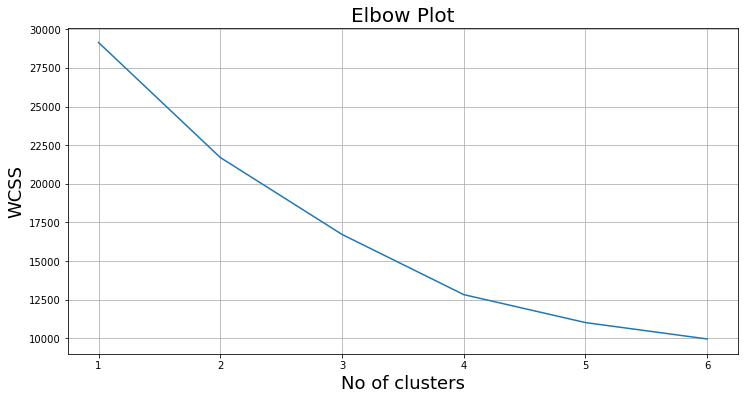

In [50]:
plt.figure(figsize=(12,6))

plt.plot(range(1,7), wcss_pca)

plt.xlabel('No of clusters',fontsize=18)
plt.ylabel('WCSS',fontsize=18)
plt.title('Elbow Plot',fontsize=20)

plt.grid(True)
plt.show()
# k=3 seems like a optimal value

In [51]:
km_pca_best = KMeans(n_clusters=3, random_state=10)
km_pca_best.fit(X_pca)

KMeans(n_clusters=3, random_state=10)

In [52]:
X_pca['Cluster_pca'] = km_pca_best.labels_
df_shoppers['Cluster_pca'] = km_pca_best.labels_
df_shoppers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Cluster,Cluster_pca
0,0,0.000000,0,0.000000,10,627.500000,0.020000,0.050000,0.000000,0.000000,Feb,3,3,1,4,Returning_Visitor,True,False,0,1
1,0,0.000000,0,0.000000,19,154.216667,0.015789,0.024561,0.000000,0.000000,Feb,2,2,1,3,Returning_Visitor,False,False,3,1
2,0,0.000000,0,0.000000,3,395.000000,0.000000,0.066667,0.000000,0.000000,Feb,1,1,3,3,Returning_Visitor,False,False,3,1
3,0,0.000000,0,0.000000,7,280.500000,0.000000,0.028571,0.000000,0.000000,Feb,1,1,1,3,Returning_Visitor,False,False,3,1
4,0,0.000000,0,0.000000,6,98.000000,0.000000,0.066667,0.000000,0.000000,Feb,2,5,1,3,Returning_Visitor,False,False,3,1


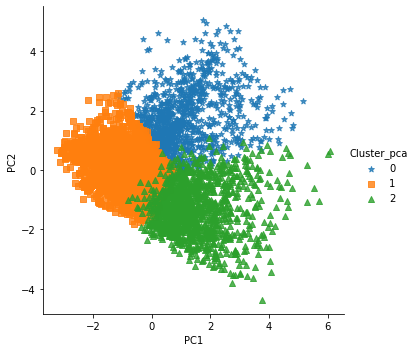

In [53]:
sns.lmplot(x='PC1',y='PC2',hue='Cluster_pca',
           data=X_pca,fit_reg=False,markers=['*',',','^'])
plt.show()

In [67]:
km_pca_best.cluster_centers_

array([[ 1.18815271,  1.77124573, -0.29148205, -0.13860666, -0.00584795],
       [-1.00335207, -0.05569719, -0.13352892,  0.03794767, -0.01254236],
       [ 1.50973953, -1.27554425,  0.55931745,  0.01756796,  0.03537352]])

In [ ]:
# the clusters are seperated and can be seen from plot and the cluster centroids

In [54]:
cluster0 = df_shoppers[df_shoppers['Cluster'] == 0]
cluster0.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Cluster,Cluster_pca
count,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000
mean,0.573813,13.221879,0.000000,0.000000,14.826701,524.551076,0.026300,0.052814,0.000000,0.000000,0.000000,0.998716
std,1.124914,31.303351,0.000000,0.000000,9.349100,476.770319,0.008107,0.016410,0.000000,0.000000,0.000000,0.297804
min,0.000000,0.000000,0.000000,0.000000,2.000000,8.000000,0.004545,0.011429,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,172.004167,0.020000,0.040683,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,12.000000,365.583333,0.025595,0.050425,0.000000,0.000000,0.000000,1.000000
75%,1.000000,3.500000,0.000000,0.000000,20.000000,733.041667,0.033333,0.064744,0.000000,0.000000,0.000000,1.000000
max,6.000000,222.500000,0.000000,0.000000,60.000000,3287.000000,0.041667,0.095238,0.000000,0.000000,0.000000,2.000000


In [55]:
cluster0.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,779,779,779,779,779,779,779,779
unique,10,6,11,9,16,2,2,2
top,Nov,2,2,1,1,Returning_Visitor,False,False
freq,208,358,511,268,248,747,600,758


In [ ]:
# Cluster 0 is the smallest with 779 datapoints. The cluster 0 has lowsest admistrative,admisnistrative_duration,product retaed and product duration 

In [60]:
cluster1 = df_shoppers[df_shoppers['Cluster'] == 1]
cluster1.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Cluster,Cluster_pca
count,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000
mean,1.120797,23.080782,0.000000,0.000000,44.726027,1764.039847,0.006087,0.020799,0.000000,0.000000,1.000000,0.004981
std,1.566196,35.589828,0.000000,0.000000,16.659257,697.063055,0.006885,0.012727,0.000000,0.000000,0.000000,0.070446
min,0.000000,0.000000,0.000000,0.000000,4.000000,441.791667,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,33.000000,1209.782449,0.000000,0.010944,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,43.000000,1668.285119,0.004348,0.018841,0.000000,0.000000,1.000000,0.000000
75%,2.000000,37.166667,0.000000,0.000000,57.000000,2251.625000,0.009850,0.028568,0.000000,0.000000,1.000000,0.000000
max,9.000000,209.062500,0.000000,0.000000,83.000000,3401.050687,0.036508,0.068651,0.000000,0.000000,1.000000,1.000000


In [61]:
cluster1.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,803,803,803,803,803,803,803,803
unique,10,5,10,9,14,3,2,2
top,Nov,2,2,1,2,Returning_Visitor,False,False
freq,295,494,555,324,270,715,612,760


In [ ]:
# Cluster 1 has 803 datapoints. The cluster 1 has moderate admistrative,admisnistrative_duration,product retaed and product duration 

In [62]:
cluster2 = df_shoppers[df_shoppers['Cluster'] == 2]
cluster2.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Cluster,Cluster_pca
count,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000
mean,4.373460,113.110879,0.000000,0.000000,18.798104,568.618413,0.003886,0.018965,0.000000,0.000000,2.000000,1.991469
std,2.007306,50.801804,0.000000,0.000000,13.051278,478.541515,0.007140,0.012658,0.000000,0.000000,0.000000,0.110730
min,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,3.000000,74.500000,0.000000,0.000000,9.000000,203.698333,0.000000,0.009190,0.000000,0.000000,2.000000,2.000000
50%,4.000000,105.750000,0.000000,0.000000,16.000000,447.166667,0.000000,0.016434,0.000000,0.000000,2.000000,2.000000
75%,6.000000,148.950000,0.000000,0.000000,26.000000,797.816667,0.005698,0.027273,0.000000,0.000000,2.000000,2.000000
max,10.000000,236.000000,0.000000,0.000000,79.000000,2923.250000,0.041463,0.066667,0.000000,0.000000,2.000000,2.000000


In [63]:
cluster2.describe(include=object)

,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,1055,1055,1055,1055,1055,1055,1055,1055
unique,10,6,11,9,18,3,2,2
top,Nov,2,2,1,2,Returning_Visitor,False,False
freq,217,480,637,375,426,675,770,1004


In [ ]:
# Cluster 2 is largest with 1055 datapoints. The cluster 2 has highest admistrative,admisnistrative_duration,product retaed and product duration 

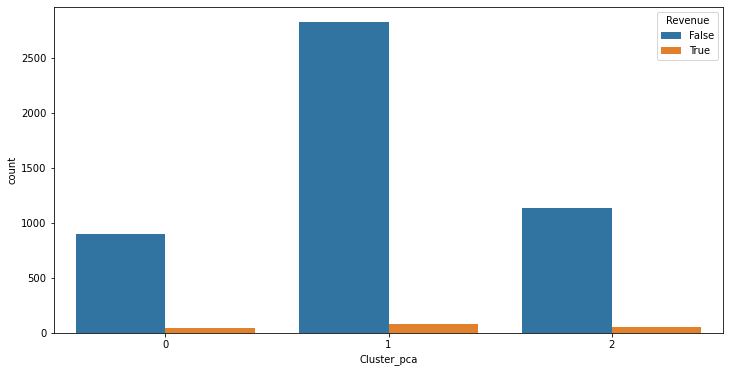

In [69]:
plt.figure(figsize=(12,6))
sns.countplot(hue=df_shoppers['Revenue'],x=df_shoppers['Cluster_pca'])
plt.show()